# **Seminar 2: Transformer Architecture

**Ashish Vaswani** and Noam Shazeer and Niki Parmar and Jakob Uszkoreit and Llion Jones and Aidan N. Gomez and Lukasz Kaiser and Illia Polosukhin. [*Attention is all you need*](https://arxiv.org/abs/1706.03762). NeurIPS 2017.

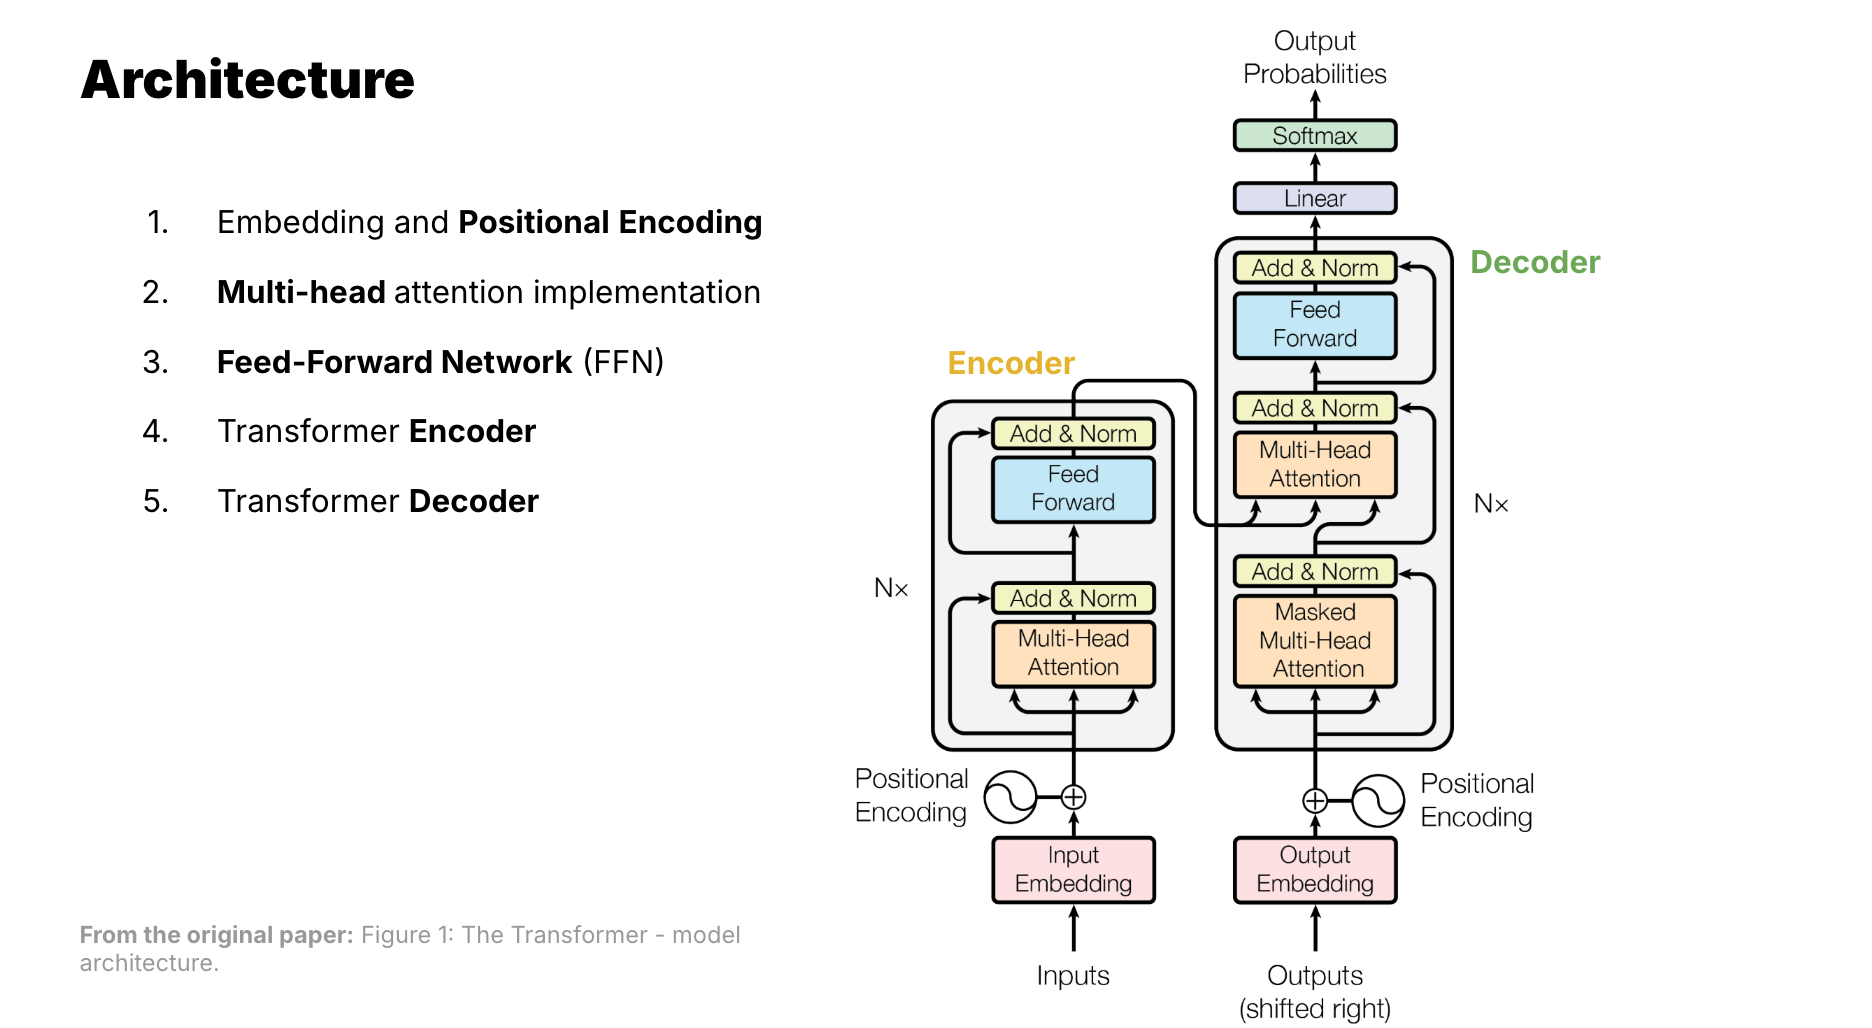

## **1. Embedding and Positional Encoding**
*Sections 3.4-3.5 of the original paper*

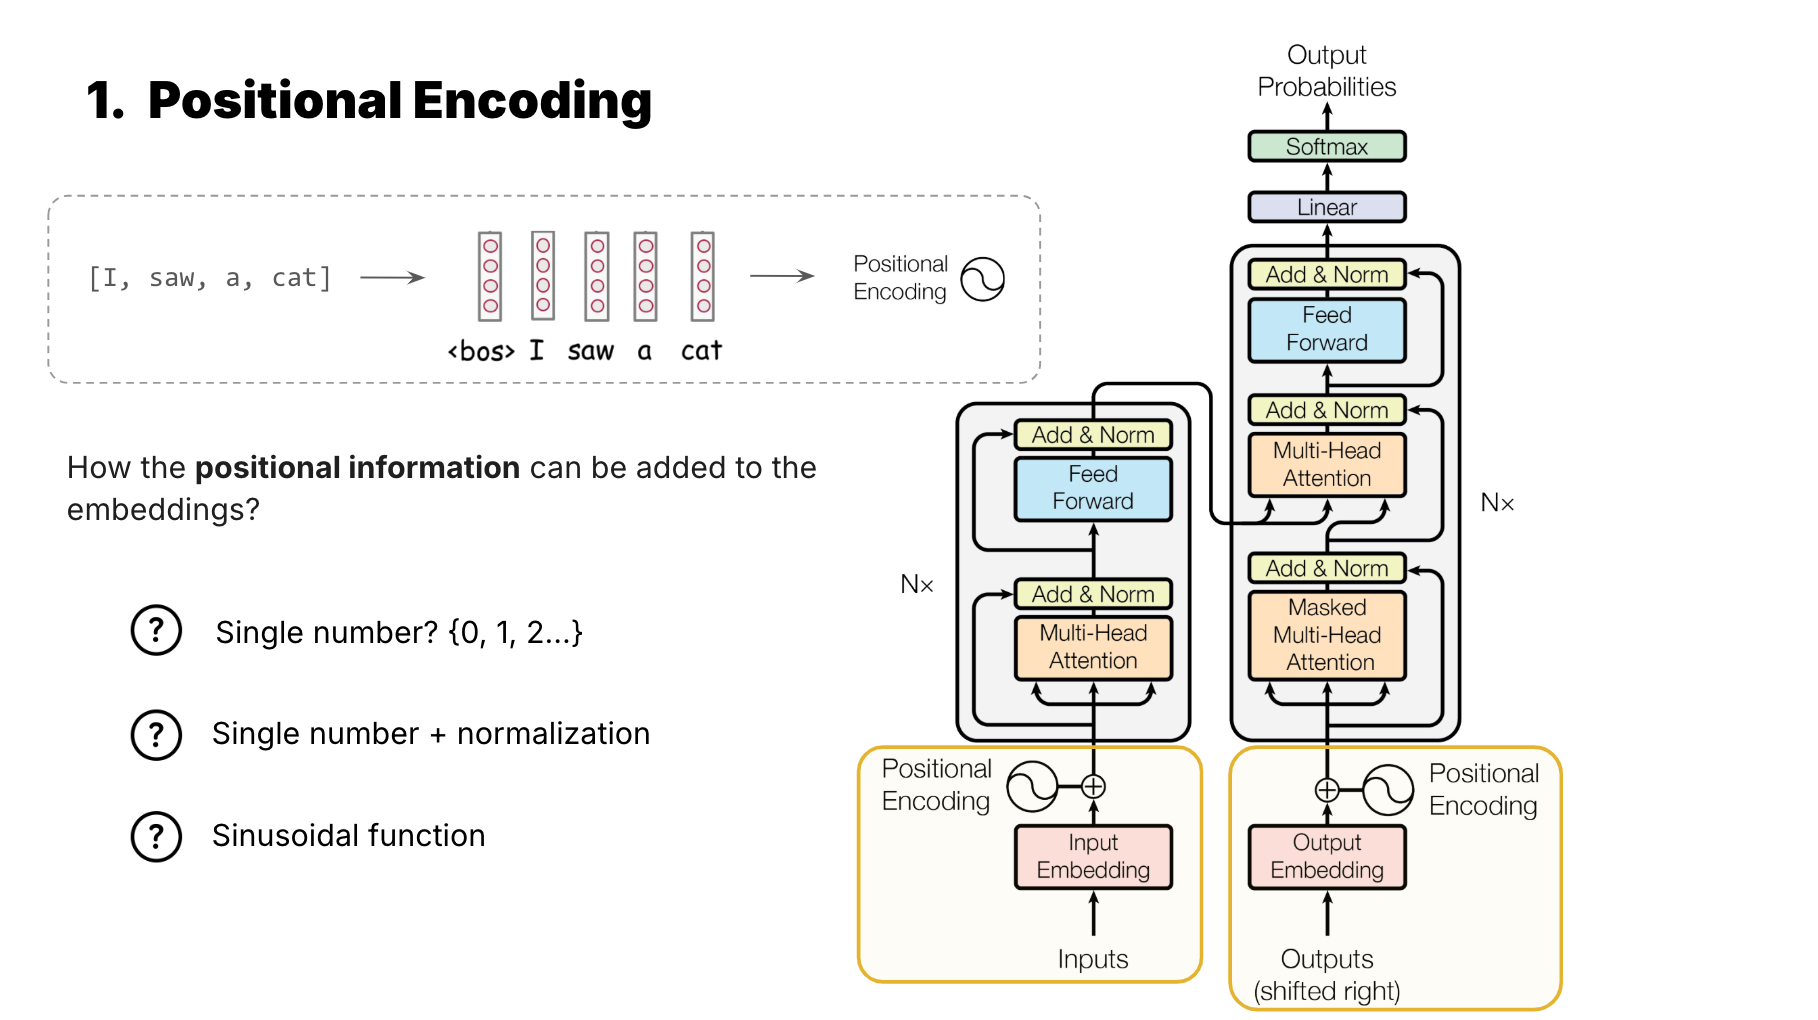

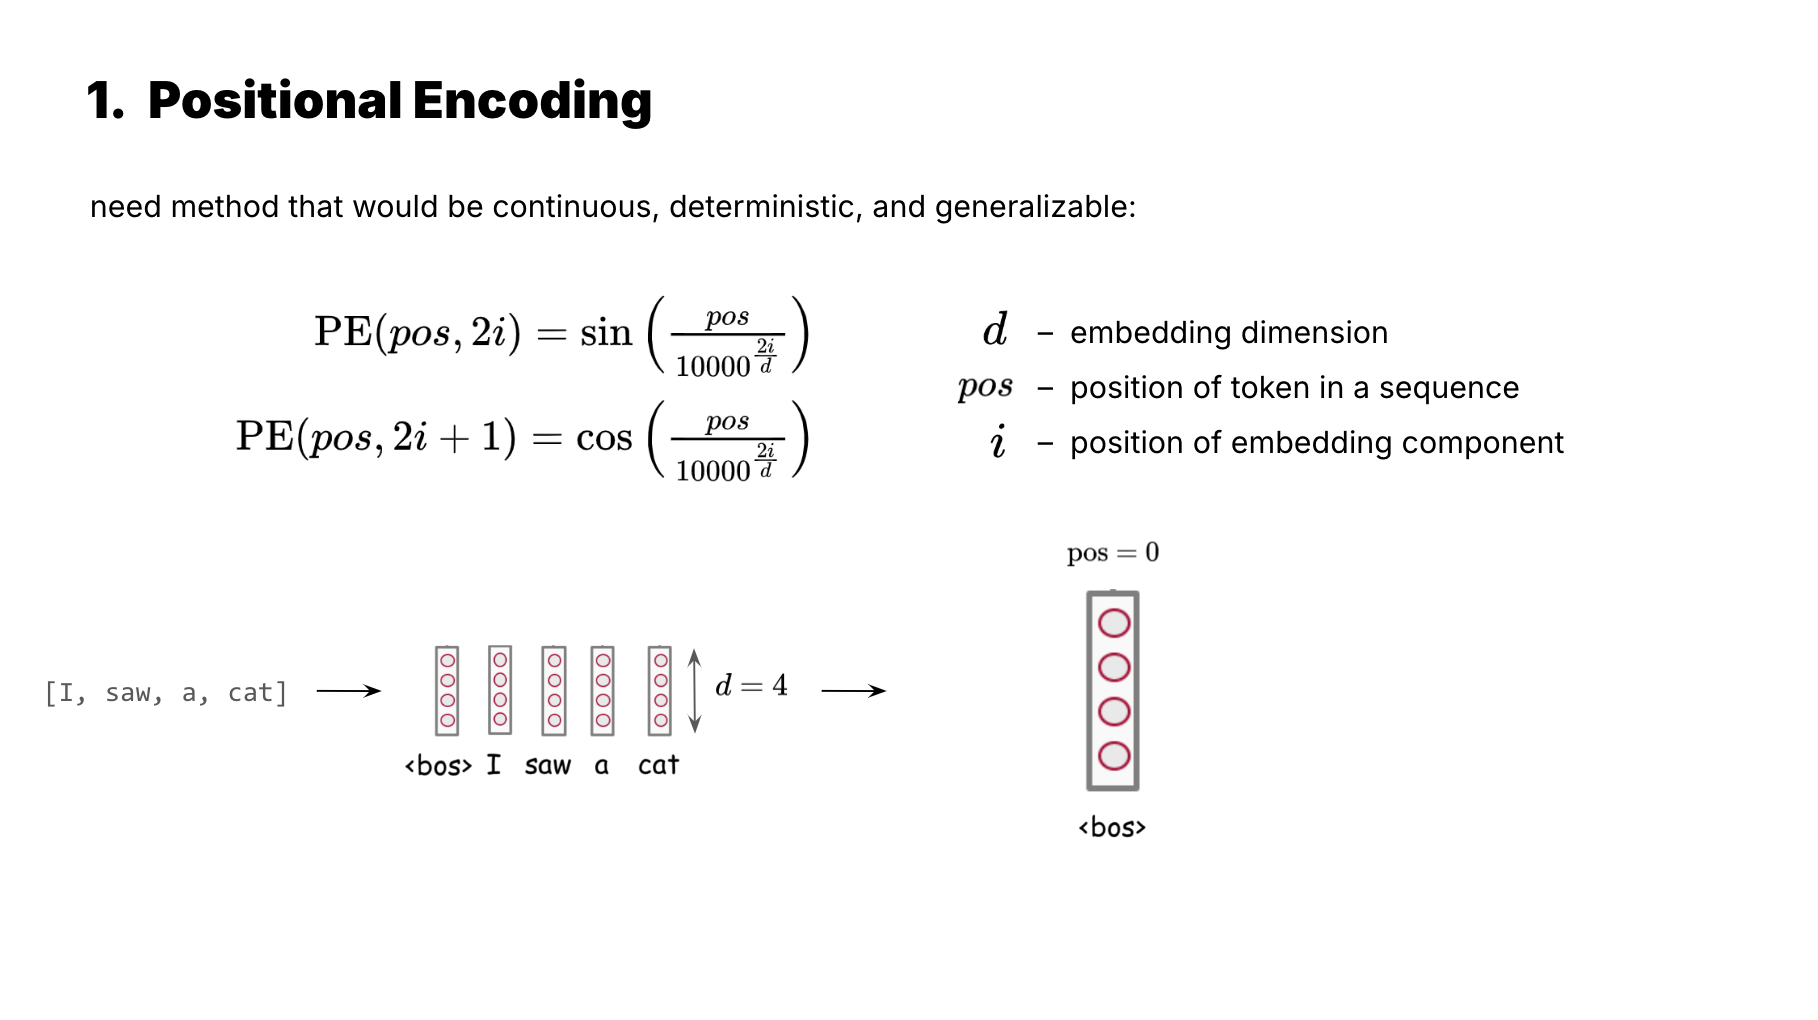

### **1.1. Implementation**

In [3]:
import math
import torch
import torch.nn as nn


class EmbeddingWithProjection(nn.Module):
    def __init__(self, vocab_size, d_embed, d_model, dropout=0.1):
        super().__init__()
        # Store d_model, d_embed, vocab_size. Create: embeddings, projection, layernorm, dropout.
        self.d_model = d_model
        self.d_embed = d_embed
        self.vocab_size = vocab_size

        self.embeddings = nn.Embedding(vocab_size, d_embed)
        self.projection = nn.Linear(d_embed, d_model)
        self.layernorm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(p=dropout)


    @staticmethod
    def create_positional_encoding(seq_length, d_model, batch_size=1, device=None):
        # Sinusoidal positional encoding: build (seq_length, d_model), then expand to (batch_size, seq_length, d_model). Use sin for even indices, cos for odd.
        pos = torch.arange(seq_length, device=device).unsqueeze(1).float()
        div = torch.exp(-math.log(10000)*torch.arange(0, d_model, 2, device = device) / d_model).float()

        pos_embeddings = torch.zeros(seq_length, d_model, device=device)
        pos_embeddings[:, ::2] = torch.sin(pos * div)
        pos_embeddings[:, 1::2] = torch.cos(pos * div)

        return pos_embeddings.unsqueeze(0).expand(batch_size, -1, -1)  # tensor of shape (batch_size, seq_length, d_model)

    def forward(self, x):
        # x: (batch_size, seq_len). Return: (batch_size, seq_len, d_model).
        # Embed -> project -> add positional encoding -> LayerNorm -> dropout.
        batch_size, seq_len = x.size()

        embed = self.embeddings(x)
        project = self.projection(embed)

        pos_encod = self.create_positional_encoding(seq_len, self.d_model, batch_size, x.device)
        normalized_sum = self.layernorm(project + pos_encod)
        final_output = self.dropout(normalized_sum)
        return final_output

### **1.2. Analysis & Interpretation**

1. dependence of the heatmap on the embedding size `d` $-$ the frequency of functions increases with increasing `d`
2. dependence of heatmap on the maximum number of tokens `pos` $-$ reproducibility


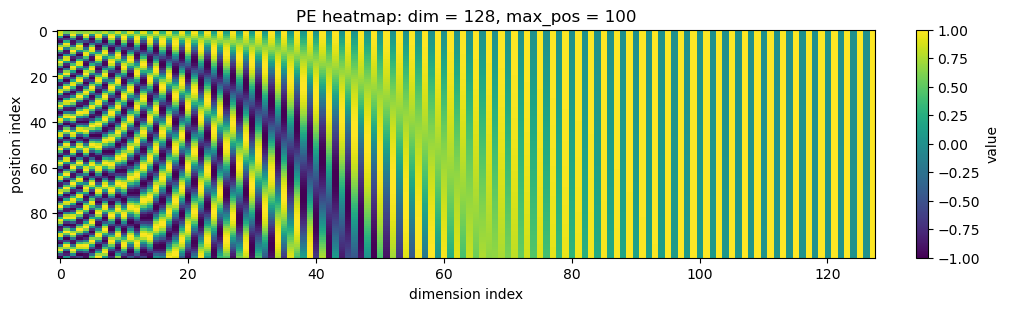

In [4]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.constrained_layout.use'] = True


ds = [128]
max_poses = [100]

for d in ds:
  for max_pos in max_poses:
    pe_demo = EmbeddingWithProjection.create_positional_encoding(
        seq_length=max_pos,
        d_model=d
    )[0]

    plt.figure(figsize=(10, 3))
    plt.title(f"PE heatmap: dim = {d}, max_pos = {max_pos}")
    plt.imshow(pe_demo, aspect='auto', interpolation='nearest')
    plt.xlabel("dimension index")
    plt.ylabel("position index")
    plt.colorbar(label="value")
    plt.show()

## **2. Multi-Head Attention Blocks**
*Section 3.2 of the original paper*


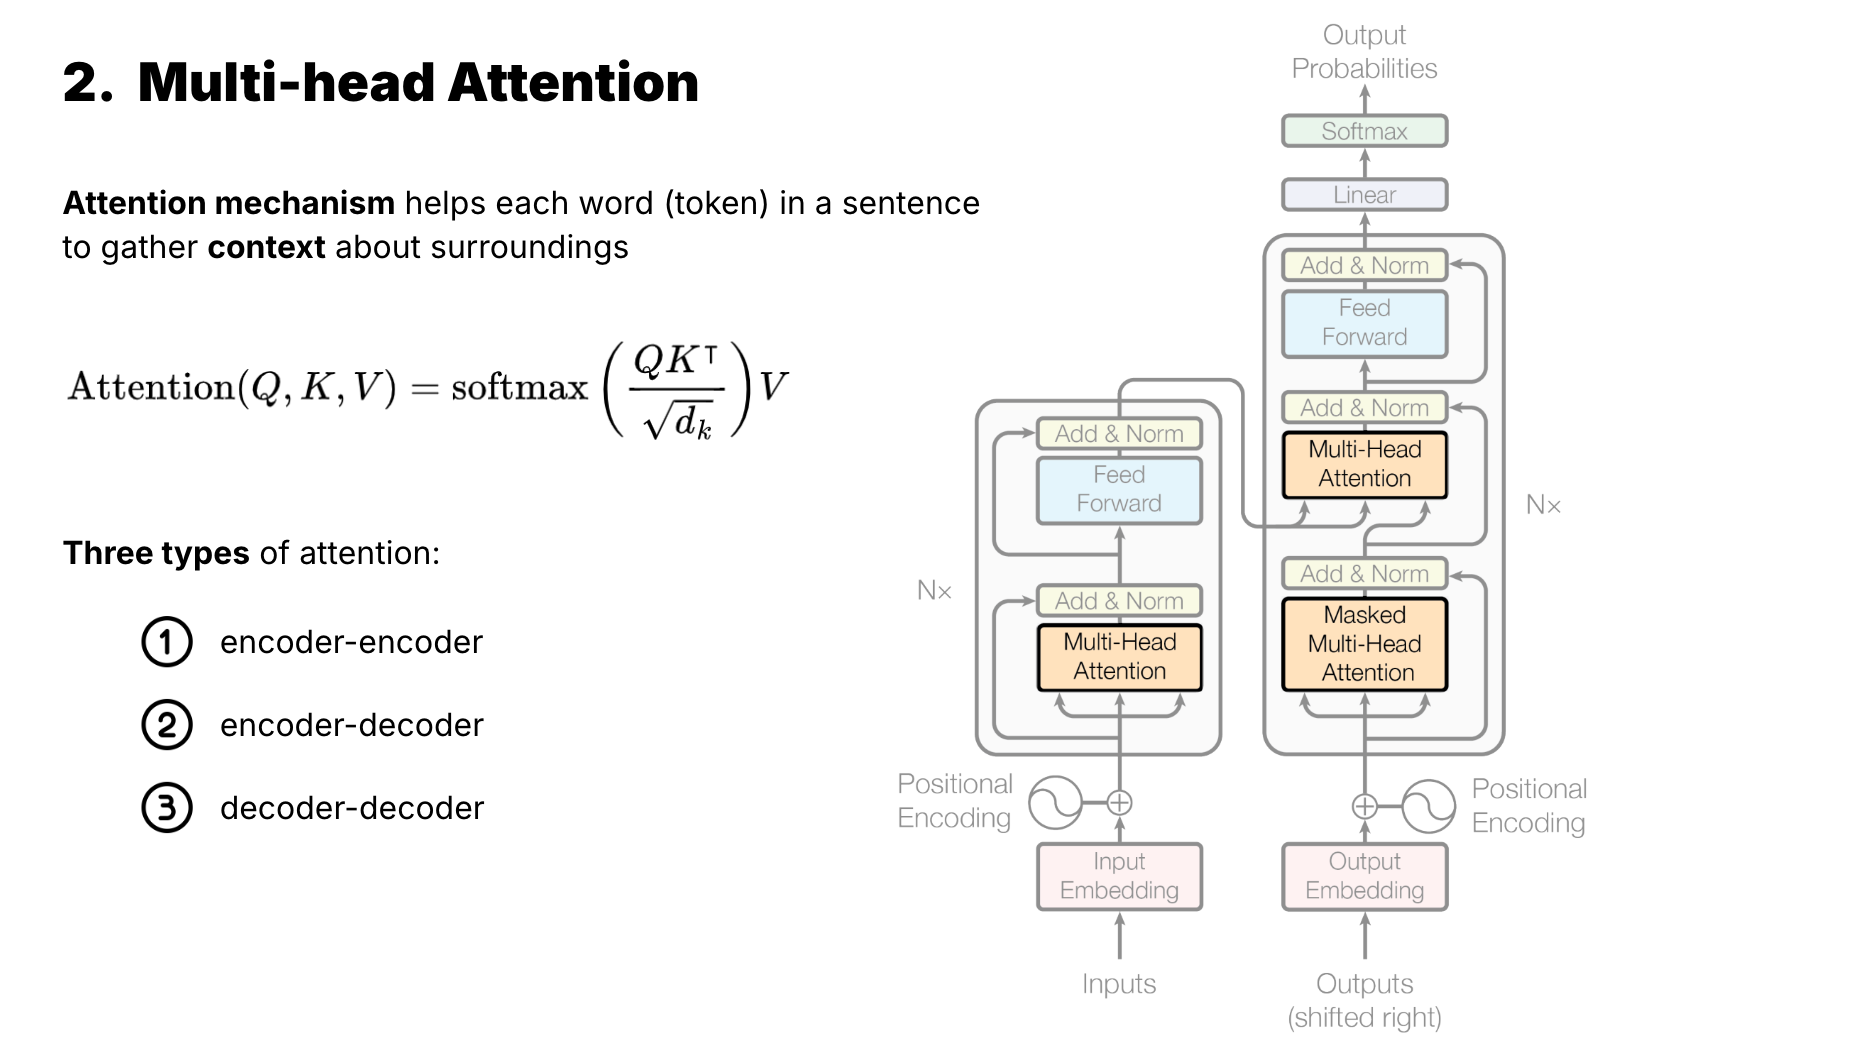

### **2.2. Multi-Head Attention**
*Section 3.2.2 of the original paper*

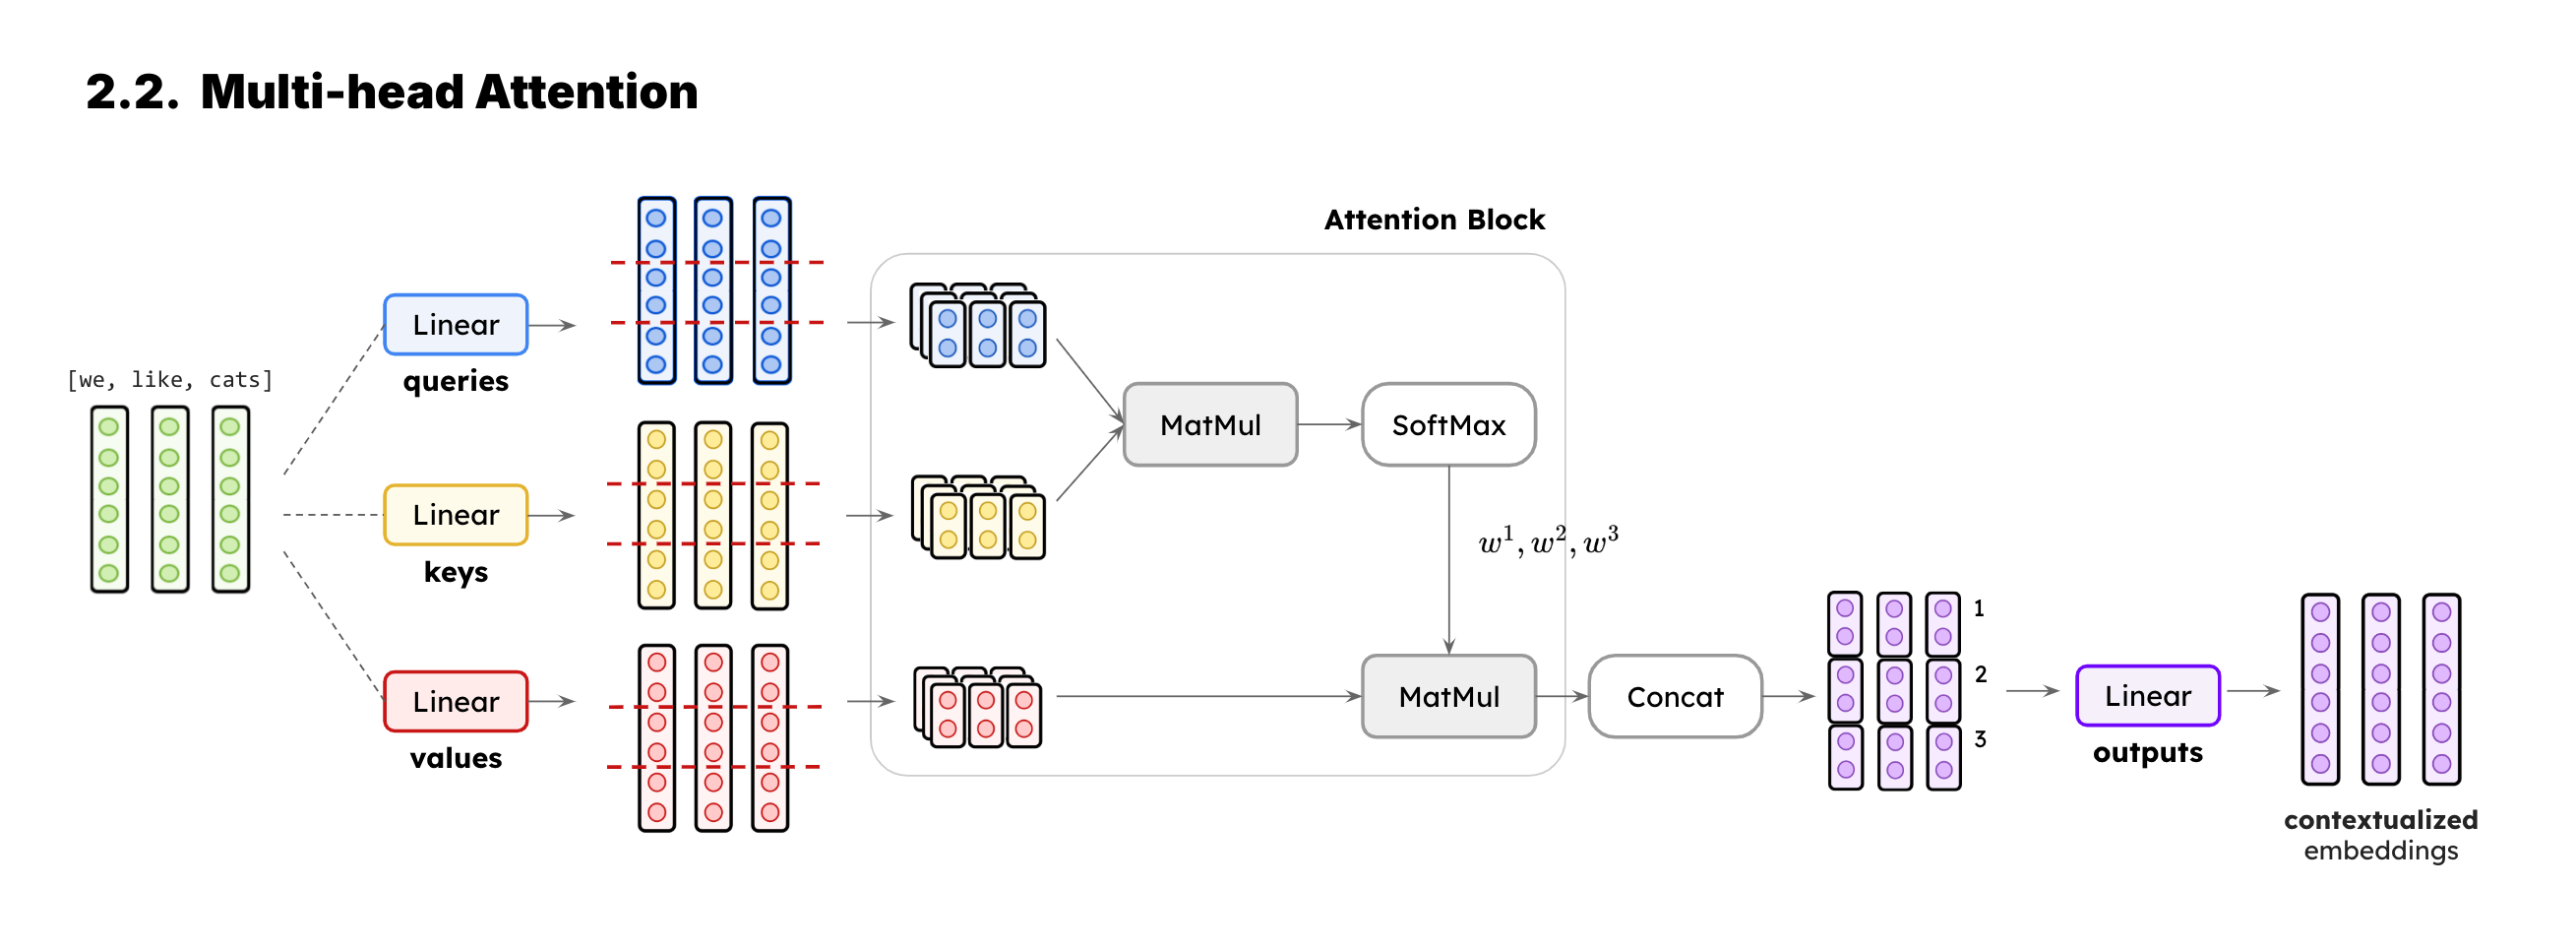

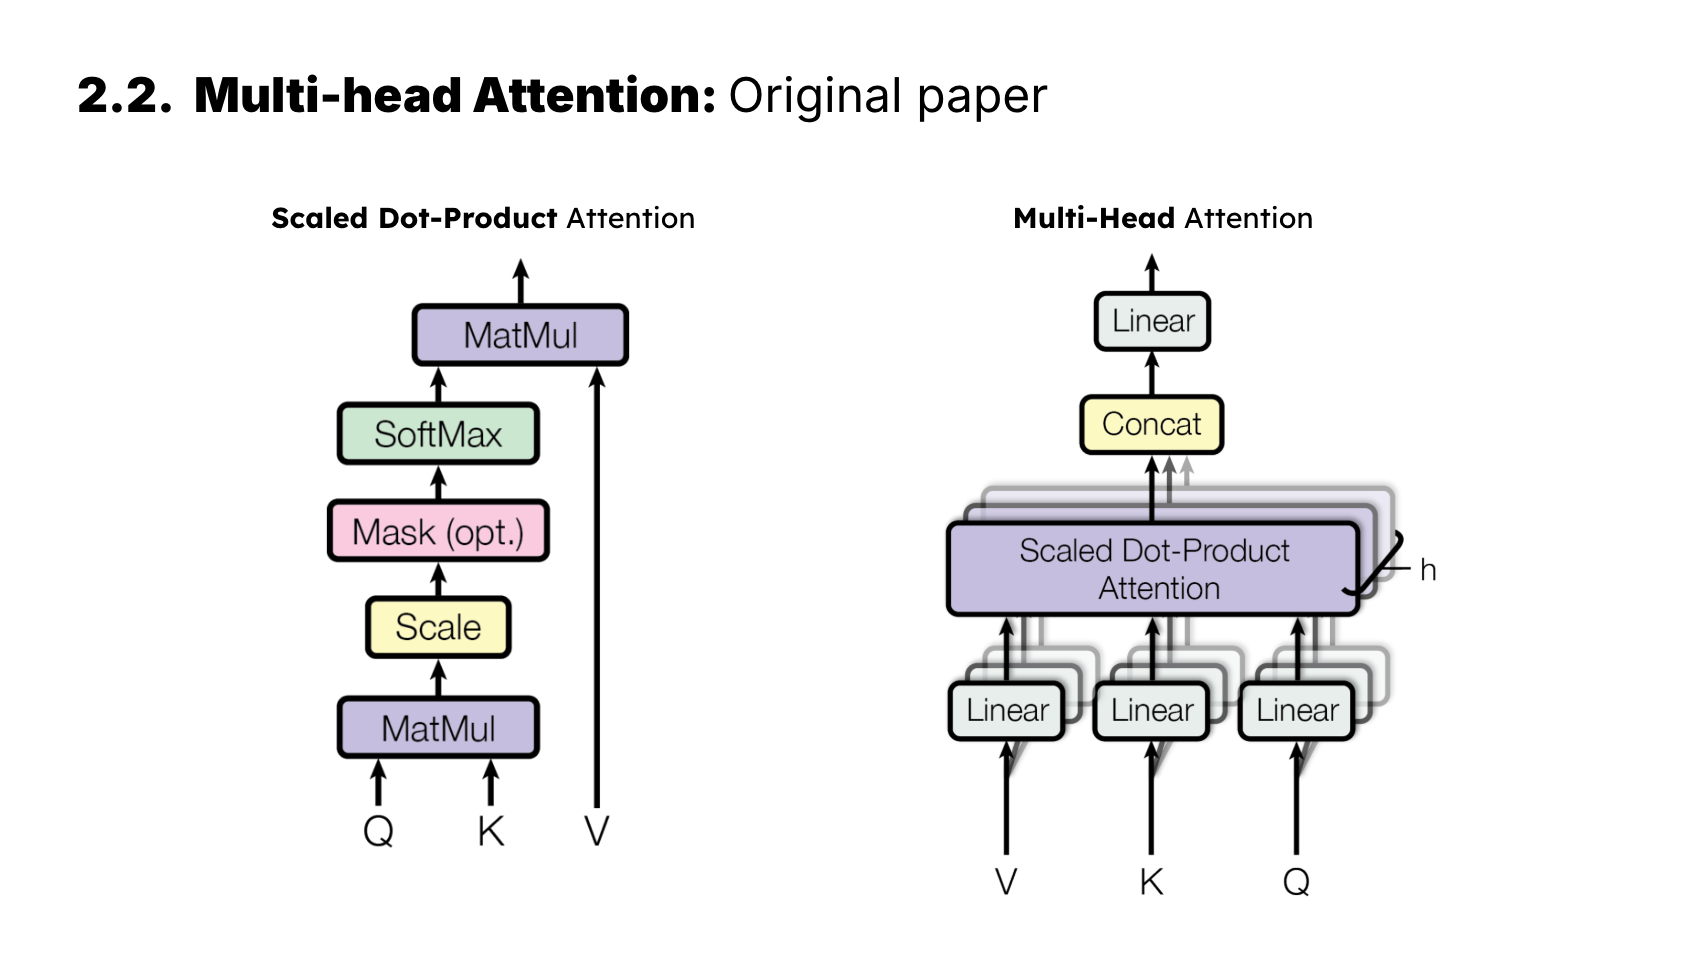

### **2.3. Implementation**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import math


class TransformerAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1, bias=True):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        # Store d_model, num_heads, d_head = d_model // num_heads. Create W_q, W_k, W_v, W_o (Linear), scaling = 1/sqrt(d_head), dropout.
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model//num_heads

        self.W_q = nn.Linear(d_model, d_model,bias=bias)
        self.W_k = nn.Linear(d_model, d_model, bias= bias)
        self.W_v = nn.Linear(d_model, d_model, bias=bias)
        self.W_o = nn.Linear(d_model, d_model, bias=bias)

        self.scaling = 1/math.sqrt(self.d_head)

        self.dropout = nn.Dropout(p=dropout)


    def _shape_heads(self, x: torch.Tensor) -> torch.Tensor:
        # [b, s, d_model] -> [b, s, num_heads, d_head] -> [b, num_heads, s, d_head]. Return contiguous tensor.
        
        b, s, _ = x.size()
        x_head = x.view(b, s, self.num_heads, self.d_head)

        x_reshaped = x_head.transpose(1,2)
        
        return x_reshaped # (b, num_heads, s, d_head)

    def forward(self, sequence, key_value_states=None, attn_mask=None):
        # sequence: (batch_size, seq_len, d_model). key_value_states=None for self-attn, else for cross-attn.
        # Compute Q from sequence; K,V from key_value_states or sequence. Scale dot-product, apply attn_mask, softmax, dropout, then output projection. Return (batch_size, seq_len, d_model).
        batch_size, seq_len, d_model = sequence.size()

        Q = self._shape_heads(self.W_q(sequence))

        if key_value_states is None:
            K, V = self._shape_heads(self.W_k(sequence)), self._shape_heads(self.W_v(sequence))
        else:
            K, V = self._shape_heads(self.W_k(key_value_states)), self._shape_heads(self.W_v(key_value_states))
        
        self.att_matrix = torch.matmul(Q, K.transpose(-2,-1)) * self.scaling

        if attn_mask is not None:
            self.att_matrix += attn_mask

        att_score = F.softmax(self.att_matrix, dim=-1)
        att_score = self.dropout(att_score)

        att_output = torch.matmul(att_score, V)
        att_output = att_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.num_heads * self.d_head)
        att_output = self.W_o(att_output)

        return att_output

## **3. Feed-Forward Network (FFN)**
*Section 3.3 of the original paper*

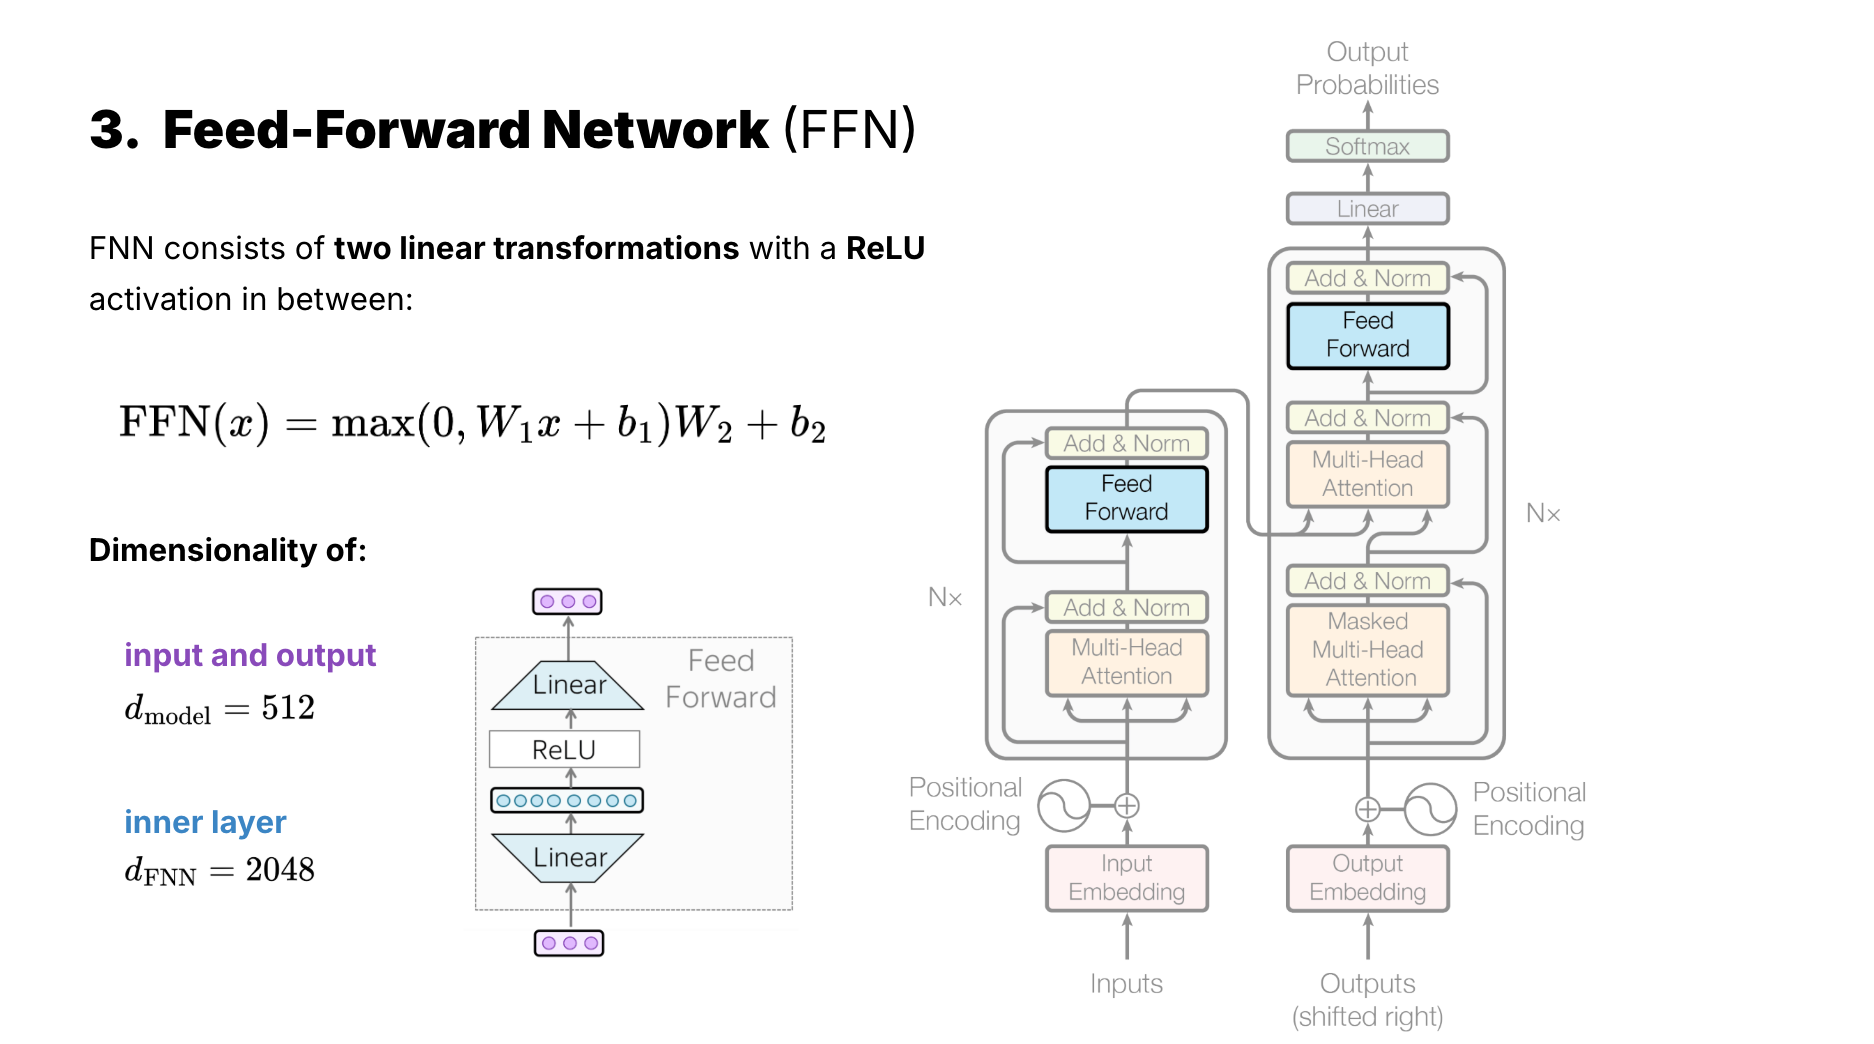

### **3.1. Implementation**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FFN(nn.Module):
    def __init__(self, d_model, d_ffn):
        super().__init__()
        # Two linear layers: d_model -> d_ffn -> d_model (with bias). Optionally Xavier init.
        self.d_model = d_model
        self.d_ffn = d_ffn

        self.l1 = nn.Linear(d_model, d_ffn, bias = True)
        self.l2 = nn.Linear(d_ffn, d_model, bias = True)

        nn.init.xavier_uniform_(self.l1.weight)
        nn.init.xavier_uniform_(self.l2.weight)
        

    def forward(self, x):
        # x: (batch_size, seq_length, d_model). Apply fc1 -> ReLU -> fc2. Return same shape.
        batch_size, seq_length, d_input = x.size()

        output = self.l2(F.relu(self.l1(x)))
        return output

## **4. Transformer Encoder**
*Section 3.1 of the original paper*

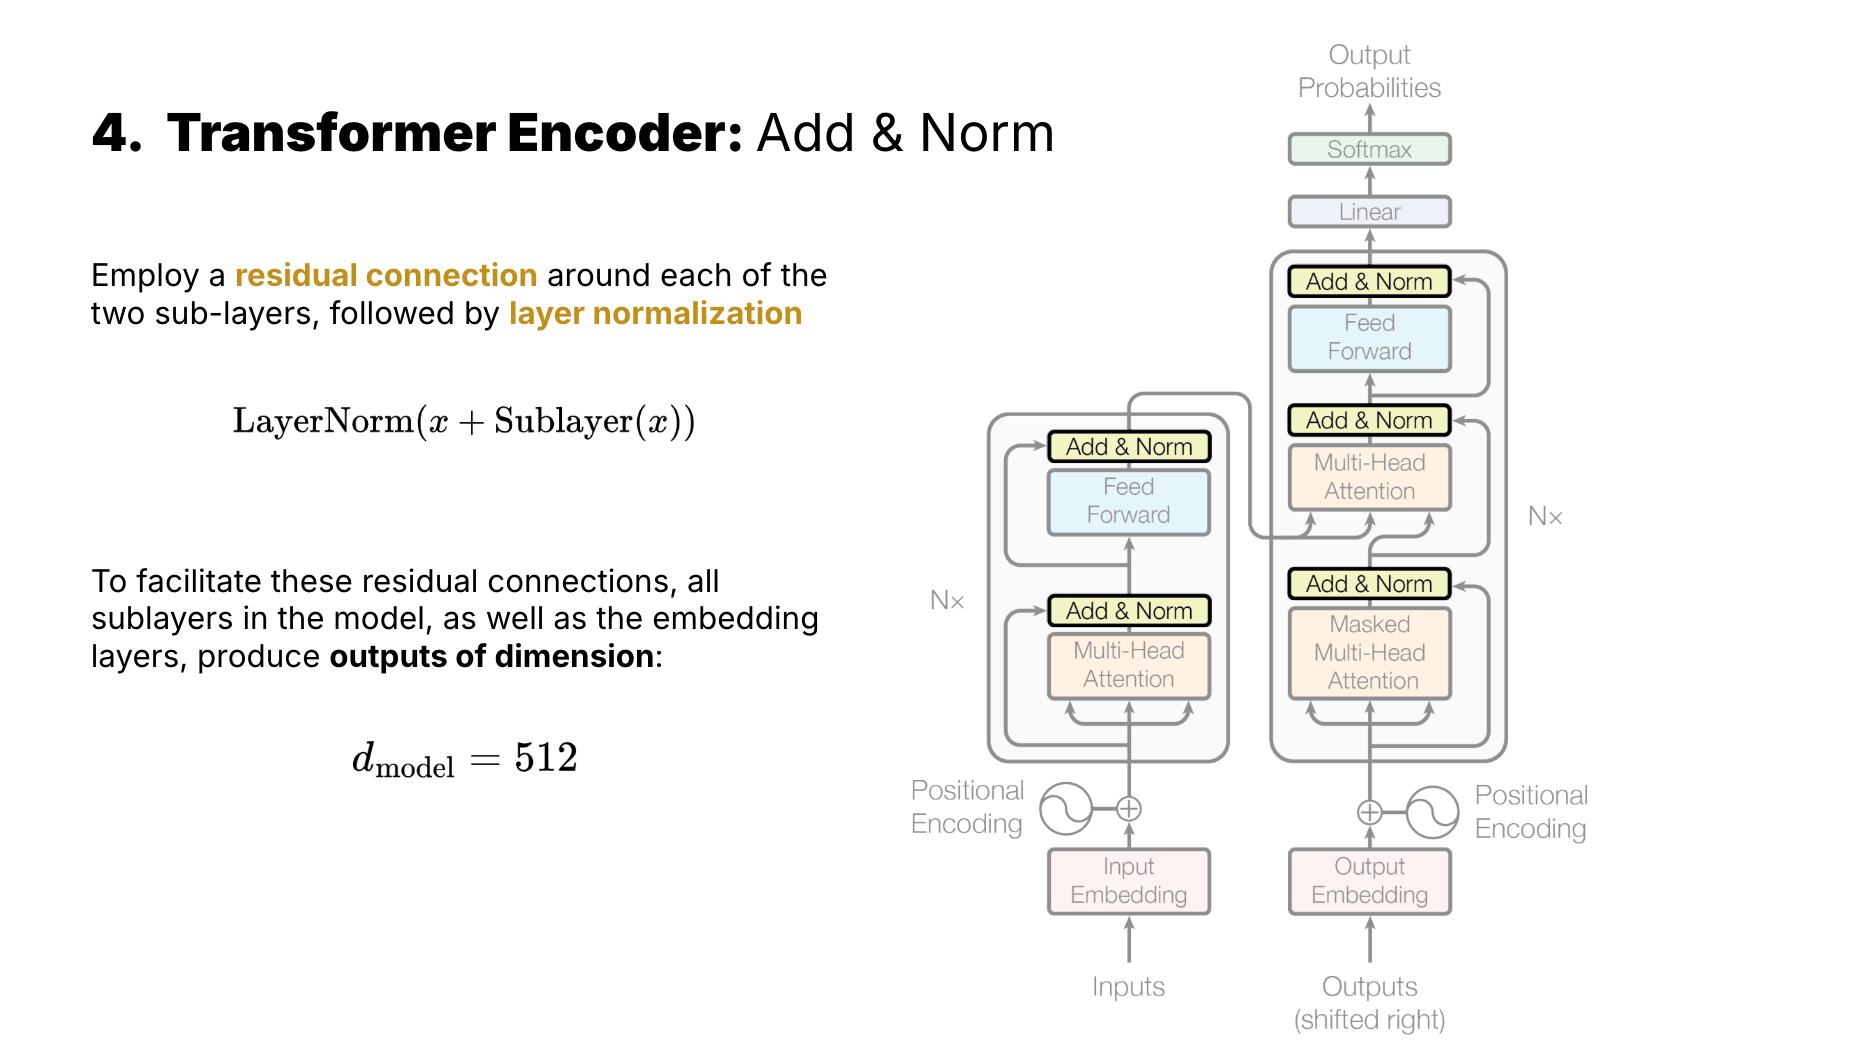

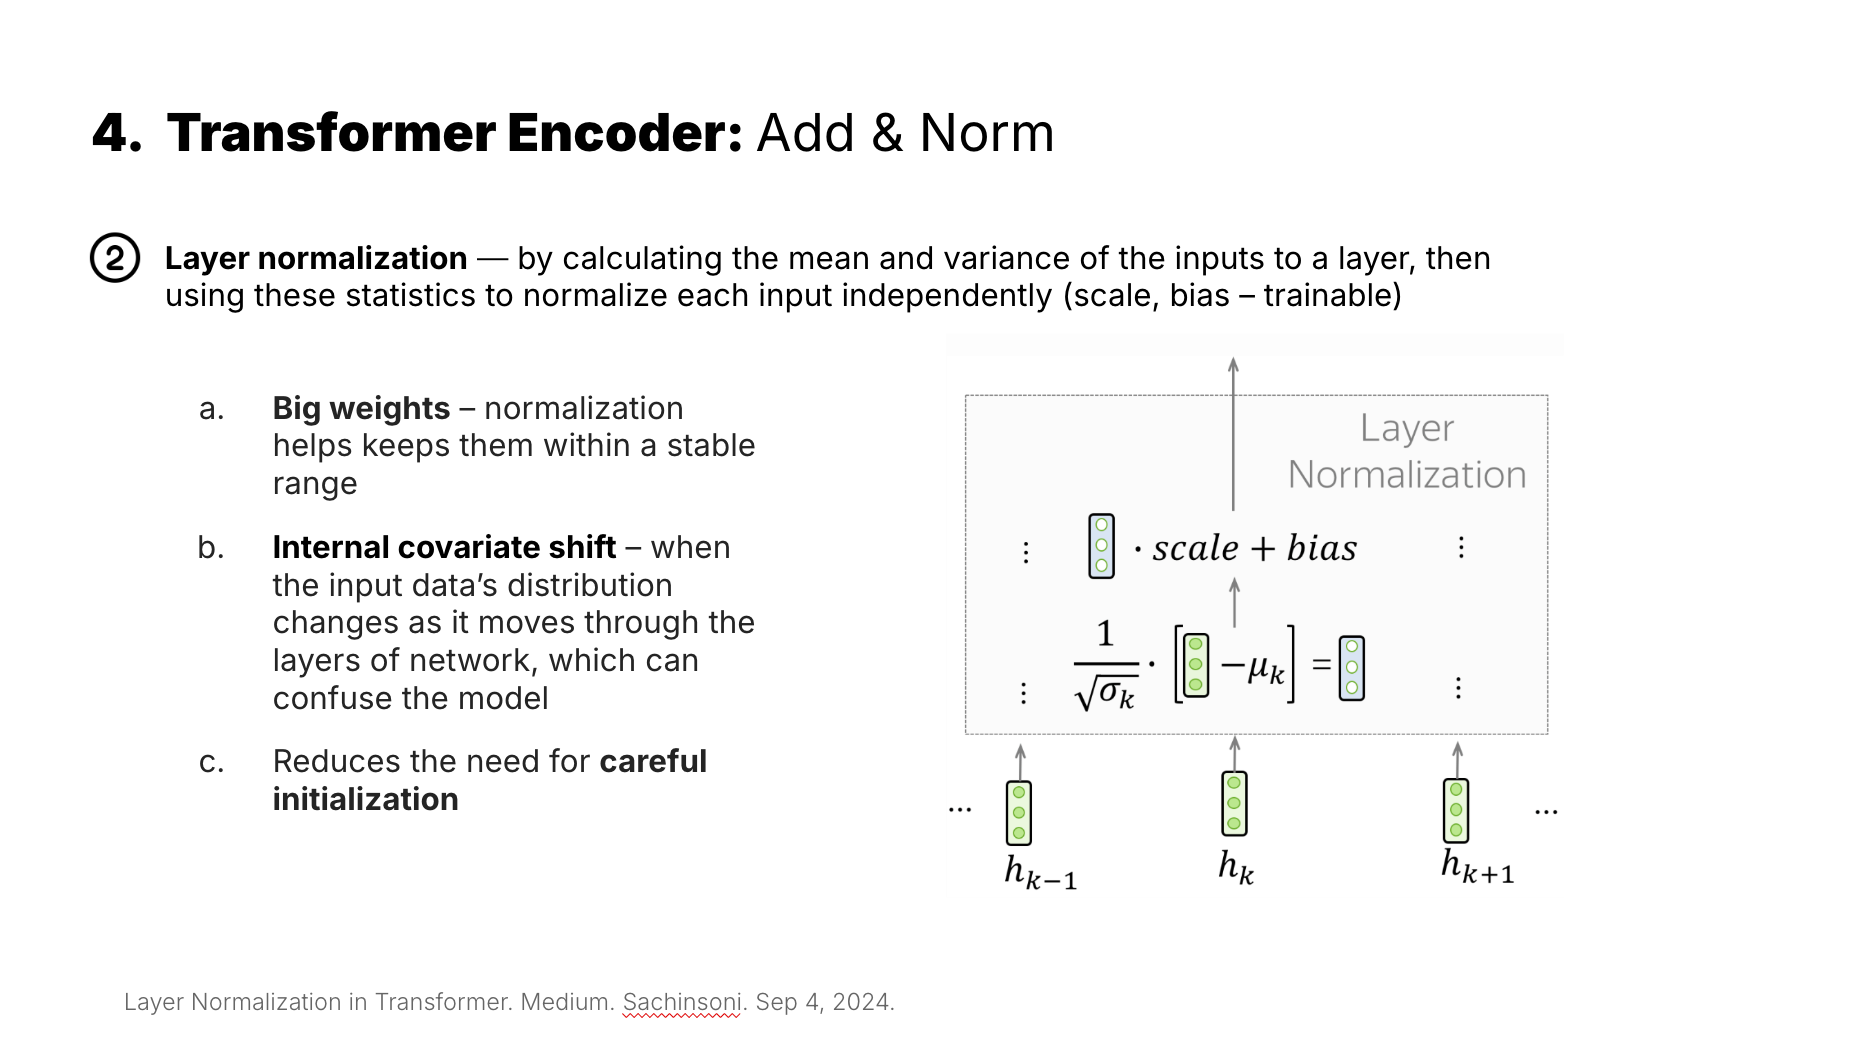

### **4.1. Implementation**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TransformerEncoder(nn.Module):
    def __init__(self, d_model, d_ffn, num_heads, dropout=0.1, bias=True):
        super().__init__()
        # One self-attention (TransformerAttention), one FFN, two LayerNorms, dropout. Store d_model, d_ffn.
        self.d_model = d_model
        self.d_ffn = d_ffn

        self.tr_att = TransformerAttention(d_model = d_model, num_heads = num_heads, dropout = dropout, bias = bias) 
        self.ffn = FFN(d_model, d_ffn)
        self.layer_norm1, self.layer_norm2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, padding_mask=None):
        # x: (batch_size, seq_len, d_model). One encoder layer: self-attn (with c) -> add & norm -> FFN -> add & norm. Return same shape.
        att_normilized = self.layer_norm1(x + self.dropout(self.tr_att(x, key_value_states = None, attn_mask = padding_mask)))
        
        ffn_normalized = self.layer_norm2(att_normilized + self.dropout(self.ffn(att_normilized)))


        return ffn_normalized

## **5. Transformer Decoder**
*Section 3.1 of the original paper*

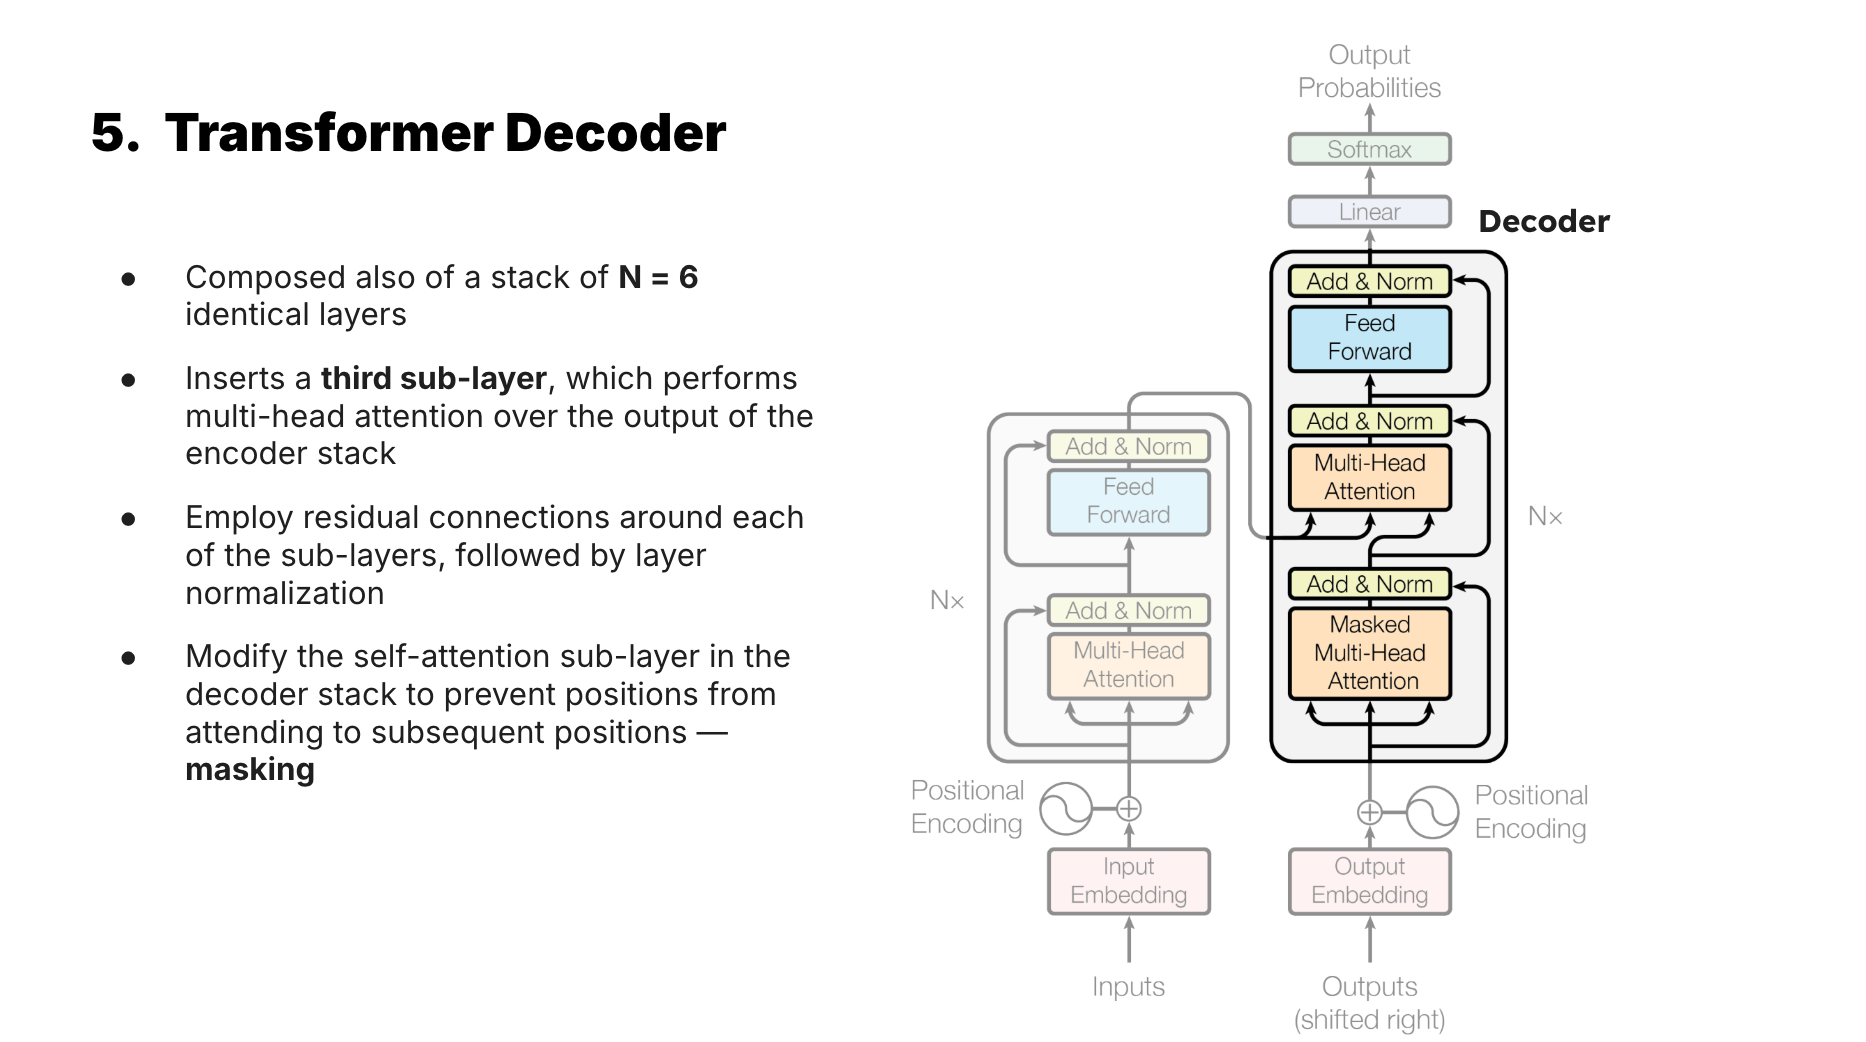

### **5.1. Implementation**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TransformerDecoder(nn.Module):
    def __init__(self, d_model, d_ffn, num_heads, dropout=0.1, bias=True):
        super().__init__()
        # Two attentions (att1 self-attn, att2 cross-attn), one FFN, three LayerNorms, dropout. Store d_model, d_ffn.
        self.attn1, self.attn2 = TransformerAttention(d_model = d_model, num_heads = num_heads, dropout = dropout, bias = bias), TransformerAttention(d_model = d_model, num_heads = num_heads, dropout = dropout, bias = bias)
        
        self.ffn = FFN(d_model = d_model, d_ffn = d_ffn)

        self.ln1, self.ln2, self.ln3 = nn.LayerNorm(d_model), nn.LayerNorm(d_model), nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(p=dropout)


    @staticmethod
    def create_causal_mask(seq_len, device=None):
        # Upper triangular mask (causal): positions (i, j) with j > i should be -inf. Return (seq_len, seq_len).
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask  # (seq_len, seq_len)

    def forward(self, x, cross_input, padding_mask=None):
        # x: decoder hidden (B, dec_len, d_model). cross_input: encoder output (B, enc_len, d_model).
        # Build causal (+ optional padding) mask for self-attn. Then: masked self-attn -> add & norm -> cross-attn (with cross_input, padding_mask) -> add & norm -> FFN -> add & norm. Return (B, dec_len, d_model).
        b_size, dec_len, d_model = x.size()
        causal_mask = self.create_causal_mask(dec_len, device = x.device).unsqueeze(0).unsqueeze(1)
        if padding_mask is not None:
            pass
        else:
            att1_mask = causal_mask

        att1 = self.attn1(
            sequence = x,
            key_value_states = None,
            attn_mask = att1_mask
        )

        att1 = self.dropout(att1)

        att1_normilized = self.ln1(x+att1)

        att2 = self.attn2(
            sequence = att1_normilized,
            key_value_states = cross_input,
            attn_mask = padding_mask
        )

        att2 = self.dropout(att2)

        att2_normilized = self.ln2(att2+att1_normilized)

        ffn = self.ffn(att2_normilized)
        ffn = self.dropout(ffn)

        ffn_normalized = self.ln3(ffn + att2_normilized)

        return ffn_normalized

## **6. Encoder-Decoder Stack**
*Section 3.1 of the original paper*

### **6.1. Implementation**

In [ ]:
class TransformerEncoderDecoder(nn.Module):
    def __init__(self, num_layer, d_model, d_ffn, num_heads, dropout=0.1, bias=True):
        super().__init__()
        # Build encoder_stack (ModuleList of num_layer TransformerEncoder) and decoder_stack (ModuleList of num_layer TransformerDecoder).
        self.encoders = nn.ModuleList([TransformerEncoder(d_model, d_ffn, num_heads, dropout, bias) for _ in range(num_layer)])
        self.decoders = nn.ModuleList([TransformerDecoder(d_model, d_ffn, num_heads, dropout, bias) for _ in range(num_layer)])


    def forward(self, embed_encoder_input, embed_decoder_input, padding_mask=None):
        # Run encoder stack on embed_encoder_input; then run decoder stack with embed_decoder_input and encoder output. Return decoder output (B, dec_len, d_model).
        x_enc = embed_encoder_input
        for encoder in self.encoders:
            x_enc = encoder(x_enc, padding_mask)
        x_dec = embed_decoder_input
        for decoder in self.decoders:
            x_dec = decoder(x_dec, x_enc, padding_mask)

        decoder_output = x_dec
        
        return decoder_output

## **7. Full Transformer!**

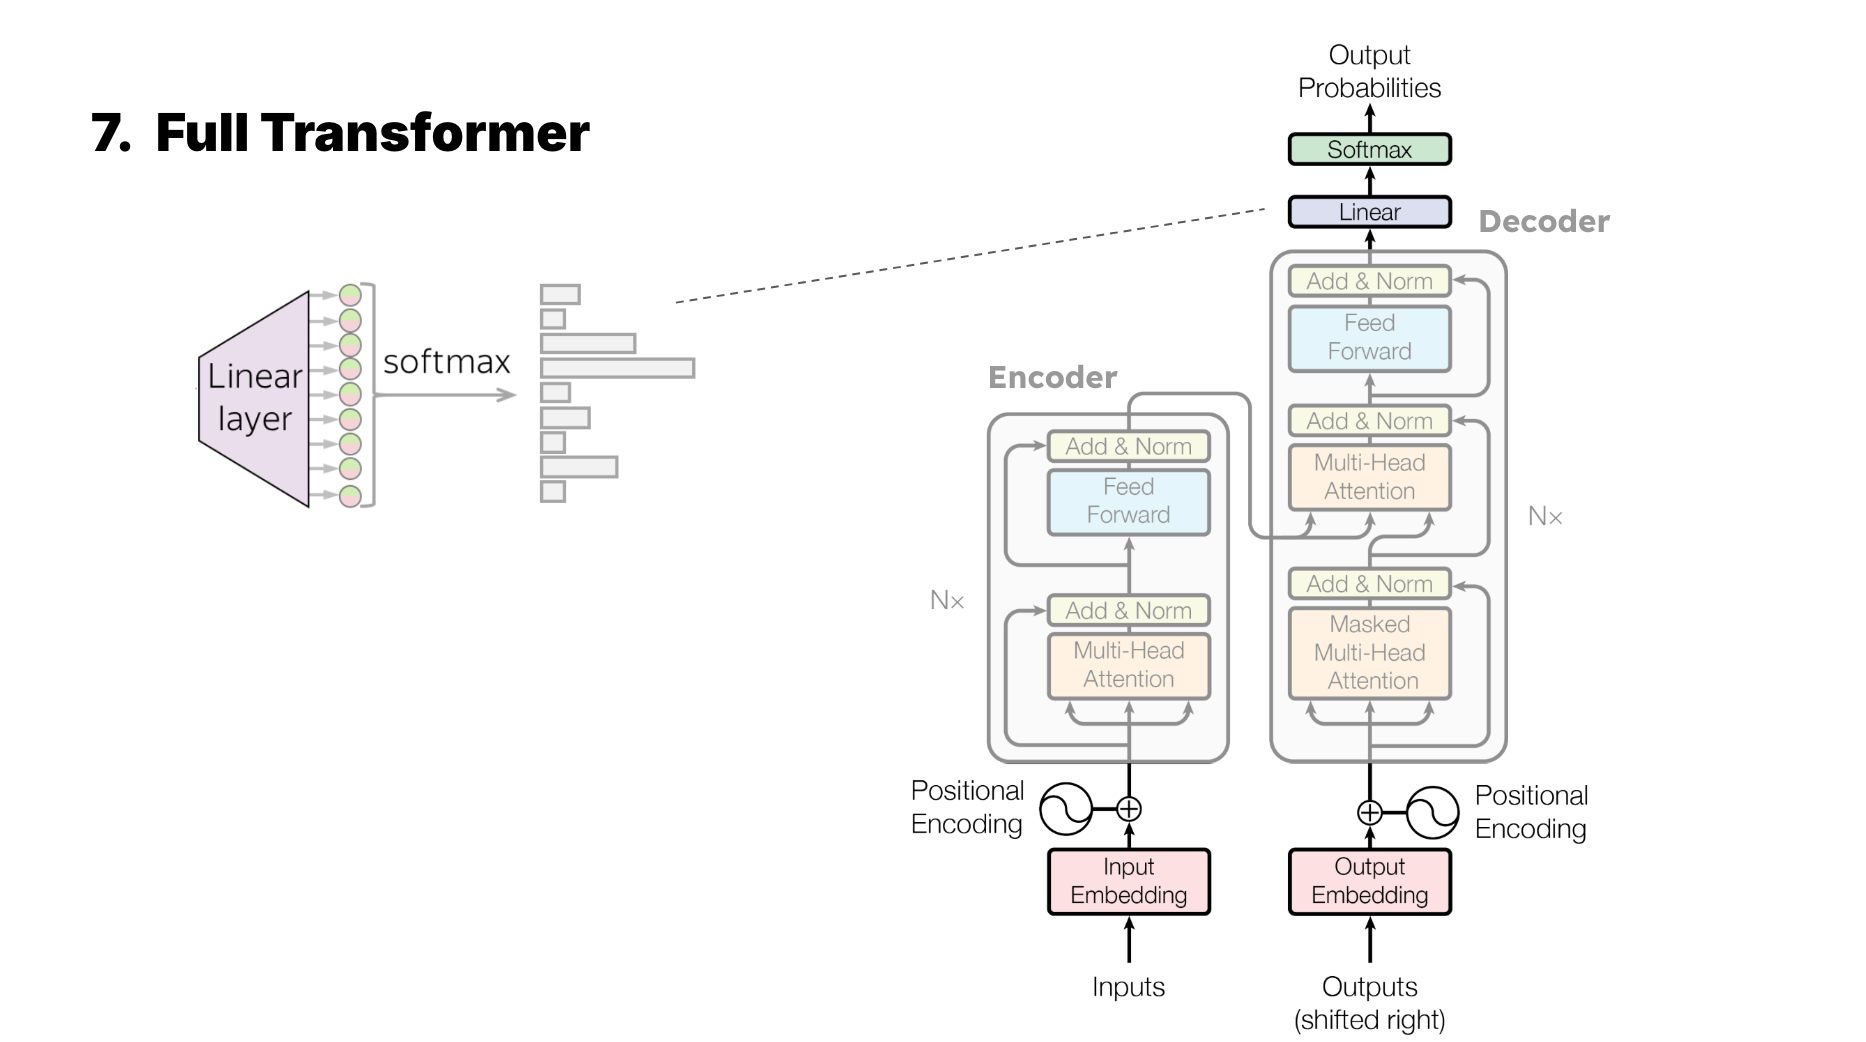

In [ ]:
class Transformer(nn.Module):
    def __init__(
        self,
        num_layer,
        d_model,
        d_embed,
        d_ffn,
        num_heads,
        src_vocab_size,
        tgt_vocab_size,
        max_position_embeddings=512,
        dropout=0.1,
        bias=True
    ):
        super().__init__()
        # Create src_embeddings and tgt_embeddings (EmbeddingWithProjection), encoder_decoder (TransformerEncoderDecoder), output_projection (Linear d_model -> tgt_vocab_size), LogSoftmax(dim=-1).
        self.src_embeddings = EmbeddingWithProjection(src_vocab_size, d_embed, d_model, dropout)
        self.tgt_embeddings = EmbeddingWithProjection(tgt_vocab_size, d_embed, d_model, dropout)
        self.enc_dec = TransformerEncoderDecoder(num_layer, d_model, d_ffn, num_heads, dropout, bias)
        self.output = nn.Linear(d_model, tgt_vocab_size)
        
        self.softmax = nn.LogSoftmax(dim=-1)

    def shift_target_right(self, tgt_tokens):
        # Prepend a zero/BOS token and drop last position so decoder sees previous targets. Return (batch_size, seq_len) same dtype/device as tgt_tokens.
        b_size, seq_len = tgt_tokens.size()

        start_tokens = torch.zeros(b_size, 1, dtype = tgt_tokens.dtype, device = tgt_tokens.device)
        shifted_tokens = torch.cat([start_tokens, tgt_tokens[:, :-1]], dim=1)
        return shifted_tokens

    def forward(self, src_tokens, tgt_tokens, padding_mask=None):
        # Shift target, embed src and tgt, run encoder_decoder, project to vocab and log_softmax. Return log_probs (B, dec_len, tgt_vocab_size).
        shifted_tgt_tokens = self.shift_target_right(tgt_tokens)

        src_embed = self.src_embeddings(src_tokens)
        tgt_embed = self.tgt_embeddings(shifted_tgt_tokens)

        decoder_output = self.enc_dec(src_embed, tgt_embed, padding_mask)
        logits = self.output(decoder_output)

        log_probs = self.softmax(logits)

        return log_probs
